# Yield curves and discount factors

Turn par quotes into dated discount factors and forward rates.

[Chapter notes](README.md) · [All topics](../../README.md)

## Research design

A quoted par rate, a zero rate and a forward rate answer different questions. A par rate makes a specified coupon instrument worth par; a discount factor prices one unit paid at a future date; a forward rate prices the exchange between two future dates.

For continuously compounded zero rates, $D(0,t)=e^{-z(t)t}$. With a declared simple accrual $\tau$, the discount-implied forward is $F(t_1,t_2)=[D(0,t_1)/D(0,t_2)-1]/\tau$. These transformations must use compatible dates and day counts.

This chapter bootstraps the versioned 1–10-year illustrative OIS par strip using explicit calendar and coupon conventions. It displays input quotes beside the zero and forward rates produced by the curve. Each helper must reprice its input within $10^{-8}$ in decimal rate units. The plot makes clear why a par quote should not be inserted directly as a zero rate.

The curve uses log-linear discount interpolation and Actual/365 Fixed zero-rate reporting. The forward-rate table uses Actual/360 accruals between adjusted annual dates. Only maturities covered by the fixture are used. Positive discount factors are required; monotonic decline is not imposed as a universal condition because negative-rate environments can imply discount factors above one.

These are constructed rates dated 15 September 2026. This chapter studies internal curve consistency; no daily Treasury series, live SOFR term surface or executable quote set is being reproduced. See the [core conventions](../../docs/01-methods.md) for the exact instrument definitions.

In [1]:
from pathlib import Path
import sys
candidates = [Path.cwd(), *Path.cwd().parents]
ROOT = next(p for p in candidates if (p / 'research' / 'pricing.py').is_file())
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import QuantLib as ql
from IPython.display import display
from research.common import RESULTS, check_hashes
from research.pricing import DATE, CAL, valuation_date, curves, fixture
plt.rcParams.update({'figure.dpi':110, 'axes.spines.top':False, 'axes.spines.right':False,
                     'axes.grid':True, 'grid.alpha':.18, 'font.size':11})
# Verify the core fixture, source and saved-output vintage before reading any summary.
check_hashes()
# Every chapter uses explicit illustrative assumptions; never a hidden data download.


## Calculation and independent checks

All inputs below are illustrative. Assertions check the identities discussed in the chapter.

In [2]:
with valuation_date():
    d, p, residuals = curves()
    quotes = fixture()
    rows=[]
    dates=[CAL.advance(DATE, ql.Period(y, ql.Years)) for y in range(1,11)]
    for y, date in enumerate(dates,1):
        t=ql.Actual365Fixed().yearFraction(DATE,date)
        start = DATE if y == 1 else dates[y-2]
        tau=ql.Actual360().yearFraction(start,date)
        rows.append({'years':y,'discount_factor':d.discount(date),'zero_rate_pct':-100*np.log(d.discount(date))/t,'annual_forward_pct':100*(d.discount(start)/d.discount(date)-1)/tau})
    curve_table=pd.DataFrame(rows).assign(par_quote_pct=100*quotes.ois_rate)
assert residuals.residual.abs().max() < 1e-8
assert (curve_table.discount_factor > 0).all()
display(curve_table.round(6))

,years,discount_factor,zero_rate_pct,annual_forward_pct,par_quote_pct
0,1,0.962902,3.780411,3.800000,3.80
1,2,0.928934,3.680815,3.596627,3.70
2,3,0.897902,3.580000,3.390171,3.60
3,4,0.868158,3.529702,3.388458,3.55
4,5,0.840278,3.478533,3.281439,3.50
5,6,0.812447,3.458589,3.369503,3.48
6,7,0.785953,3.438141,3.324734,3.46
7,8,0.759988,3.428311,3.369715,3.45
8,9,0.734911,3.418124,3.347143,3.44
9,10,0.711023,3.407709,3.322811,3.43


## Economic relationship

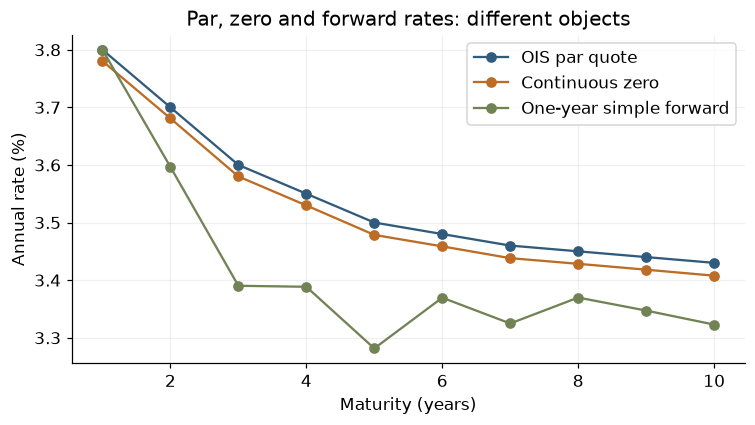

In [3]:
fig,ax=plt.subplots(figsize=(7,4))
for col,label,color in [('par_quote_pct','OIS par quote','#315b7d'),('zero_rate_pct','Continuous zero','#bc6c25'),('annual_forward_pct','One-year simple forward','#718355')]:
    ax.plot(curve_table.years,curve_table[col],marker='o',label=label,color=color)
ax.set(xlabel='Maturity (years)',ylabel='Annual rate (%)',title='Par, zero and forward rates: different objects')
ax.legend();fig.tight_layout();plt.show()

## Interpretation

The same calibrated curve produces distinct par, zero and forward rates. Small repricing errors establish consistency with the declared inputs, not the accuracy of those inputs as market observations.